<a href="https://colab.research.google.com/github/SuganeshInsights/RFM-Customer-Segmentation/blob/feature%2Frfm-customer-insights/RFM_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.ensemble import GradientBoostingRegressor


In [ ]:
df=pd.read_excel("http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.dropna(inplace=True)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
df.duplicated().sum()

5225

In [ ]:
df.drop_duplicates(inplace=True)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
current_date=df["InvoiceDate"].max()
recency_data=df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
print(recency_data.head())
recency_data["Recency"]=(current_date-recency_data["InvoiceDate"]).dt.days
print(recency_data[["CustomerID","Recency"]].head(10))

   CustomerID         InvoiceDate
0     12346.0 2011-01-18 10:17:00
1     12347.0 2011-12-07 15:52:00
2     12348.0 2011-09-25 13:13:00
3     12349.0 2011-11-21 09:51:00
4     12350.0 2011-02-02 16:01:00
   CustomerID  Recency
0     12346.0      325
1     12347.0        1
2     12348.0       74
3     12349.0       18
4     12350.0      309
5     12352.0       35
6     12353.0      203
7     12354.0      231
8     12355.0      213
9     12356.0       22


In [ ]:
frequency_data=df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
print(frequency_data)
frequency_data.columns=["CustomerID","Frequency"]
print(frequency_data)

      CustomerID  InvoiceNo
0        12346.0          2
1        12347.0          7
2        12348.0          4
3        12349.0          1
4        12350.0          1
...          ...        ...
4367     18280.0          1
4368     18281.0          1
4369     18282.0          3
4370     18283.0         16
4371     18287.0          3

[4372 rows x 2 columns]
      CustomerID  Frequency
0        12346.0          2
1        12347.0          7
2        12348.0          4
3        12349.0          1
4        12350.0          1
...          ...        ...
4367     18280.0          1
4368     18281.0          1
4369     18282.0          3
4370     18283.0         16
4371     18287.0          3

[4372 rows x 2 columns]


In [ ]:
df["TotalPrice"]=df["Quantity"]*df["UnitPrice"]

In [ ]:
monetary_data=df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary_data.columns=['CustomerID','Monetary']
print(monetary_data.head(10))

   CustomerID  Monetary
0     12346.0      0.00
1     12347.0   4310.00
2     12348.0   1797.24
3     12349.0   1757.55
4     12350.0    334.40
5     12352.0   1545.41
6     12353.0     89.00
7     12354.0   1079.40
8     12355.0    459.40
9     12356.0   2811.43


In [ ]:
rfm_data=pd.merge(recency_data,frequency_data)
rfm_data=pd.merge(rfm_data,monetary_data,on="CustomerID",how="inner")
rfm_data

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:17:00,325,2,0.00
1,12347.0,2011-12-07 15:52:00,1,7,4310.00
2,12348.0,2011-09-25 13:13:00,74,4,1797.24
3,12349.0,2011-11-21 09:51:00,18,1,1757.55
4,12350.0,2011-02-02 16:01:00,309,1,334.40
...,...,...,...,...,...
4367,18280.0,2011-03-07 09:52:00,277,1,180.60
4368,18281.0,2011-06-12 10:53:00,180,1,80.82
4369,18282.0,2011-12-02 11:43:00,7,3,176.60
4370,18283.0,2011-12-06 12:02:00,3,16,2045.53


In [ ]:
rfm_data.drop("InvoiceDate",inplace=True,axis=1)
rfm_data

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,0.00
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40
...,...,...,...,...
4367,18280.0,277,1,180.60
4368,18281.0,180,1,80.82
4369,18282.0,7,3,176.60
4370,18283.0,3,16,2045.53


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
wss=[]
for k in range(2,11):
  model= KMeans(n_clusters=k,init='k-means++',max_iter=300,n_init=10,random_state=11)#kmeans++=to find best centroid,init=checking 10 times
  model.fit(rfm_data)
  wss.append(model.inertia_)

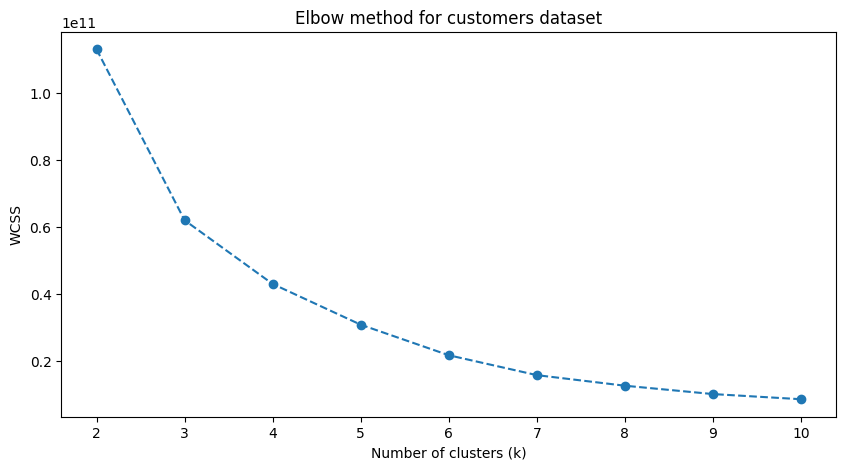

In [ ]:
#plotting the WSS
plt.figure(figsize=(10,5))
plt.plot(range(2,11),wss,marker='o',linestyle='--')
plt.title('Elbow method for customers dataset')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
#rfm_data=rfm_data.drop('Cluster',axis=1)
#rfm_data

In [ ]:
#finding labels
model= KMeans(n_clusters=4,init='k-means++',max_iter=300,n_init=10,random_state=16)#kmeans++=to find best centroid,init=checking 10 times
model.fit(rfm_data)
rfm_data['cluster']=model.labels_
rfm_data

,CustomerID,Recency,Frequency,Monetary,cluster
0,12346.0,325,2,0.00,2
1,12347.0,1,7,4310.00,2
2,12348.0,74,4,1797.24,2
3,12349.0,18,1,1757.55,2
4,12350.0,309,1,334.40,2
...,...,...,...,...,...
4367,18280.0,277,1,180.60,2
4368,18281.0,180,1,80.82,2
4369,18282.0,7,3,176.60,2
4370,18283.0,3,16,2045.53,2


In [ ]:
sil_score=silhouette_score(rfm_data,model.labels_)
print('silhouette_score:',sil_score)

silhouette_score: 0.7823075285468934


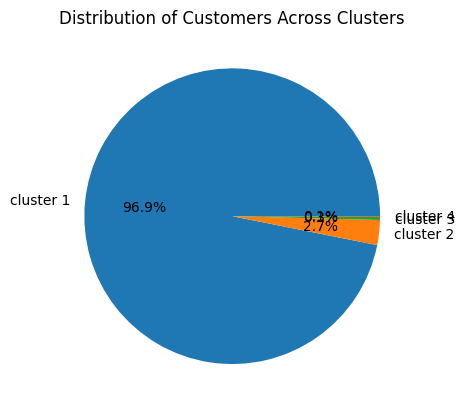

In [ ]:
cluster_counts = rfm_data['cluster'].value_counts()
labels = [f'cluster {i + 1}' for i in range(4)]

plt.pie(cluster_counts, labels=labels, autopct='%1.1f%%')
plt.title('Distribution of Customers Across Clusters')
plt.show()

In [ ]:
rfm_data

,CustomerID,Recency,Frequency,Monetary,cluster
0,12346.0,325,2,0.00,2
1,12347.0,1,7,4310.00,2
2,12348.0,74,4,1797.24,2
3,12349.0,18,1,1757.55,2
4,12350.0,309,1,334.40,2
...,...,...,...,...,...
4367,18280.0,277,1,180.60,2
4368,18281.0,180,1,80.82,2
4369,18282.0,7,3,176.60,2
4370,18283.0,3,16,2045.53,2


In [ ]:
#Analysis using rfm_score
rfm_data['r_rank']=rfm_data['Recency'].rank(ascending=False) #give higher rank to the customers for recent purchase
rfm_data['f_rank']=rfm_data['Frequency'].rank(ascending=True)
rfm_data['m_rank']=rfm_data['Monetary'].rank(ascending=True)
rfm_data

,CustomerID,Recency,Frequency,Monetary,cluster,r_rank,f_rank,m_rank
0,12346.0,325,2,0.00,2,167.0,1722.0,46.5
1,12347.0,1,7,4310.00,2,4221.5,3560.0,4054.0
2,12348.0,74,4,1797.24,2,1649.5,2809.0,3398.0
3,12349.0,18,1,1757.55,2,3152.5,657.0,3372.0
4,12350.0,309,1,334.40,2,241.0,657.0,1309.0
...,...,...,...,...,...,...,...,...
4367,18280.0,277,1,180.60,2,362.0,657.0,635.0
4368,18281.0,180,1,80.82,2,863.5,657.0,159.0
4369,18282.0,7,3,176.60,2,3785.5,2375.5,606.5
4370,18283.0,3,16,2045.53,2,4012.0,4146.5,3522.0


In [ ]:
#do Normalization
rfm_data['r_rank_norm']=(rfm_data['r_rank']/rfm_data['r_rank'].max())*100
rfm_data['f_rank_norm']=(rfm_data['f_rank']/rfm_data['f_rank'].max())*100
rfm_data['m_rank_norm']=(rfm_data['m_rank']/rfm_data['m_rank'].max())*100
rfm_data

,CustomerID,Recency,Frequency,Monetary,cluster,r_rank,f_rank,m_rank,r_rank_norm,f_rank_norm,m_rank_norm
0,12346.0,325,2,0.00,2,167.0,1722.0,46.5,3.865741,39.387008,1.063586
1,12347.0,1,7,4310.00,2,4221.5,3560.0,4054.0,97.719907,81.427264,92.726441
2,12348.0,74,4,1797.24,2,1649.5,2809.0,3398.0,38.182870,64.249771,77.721866
3,12349.0,18,1,1757.55,2,3152.5,657.0,3372.0,72.974537,15.027447,77.127173
4,12350.0,309,1,334.40,2,241.0,657.0,1309.0,5.578704,15.027447,29.940531
...,...,...,...,...,...,...,...,...,...,...,...
4367,18280.0,277,1,180.60,2,362.0,657.0,635.0,8.379630,15.027447,14.524245
4368,18281.0,180,1,80.82,2,863.5,657.0,159.0,19.988426,15.027447,3.636780
4369,18282.0,7,3,176.60,2,3785.5,2375.5,606.5,87.627315,54.334401,13.872370
4370,18283.0,3,16,2045.53,2,4012.0,4146.5,3522.0,92.870370,94.842177,80.558097


In [ ]:
rfm_data.drop(['r_rank','f_rank','m_rank'],axis=1,inplace=True)
rfm_data

,CustomerID,Recency,Frequency,Monetary,cluster,r_rank_norm,f_rank_norm,m_rank_norm
0,12346.0,325,2,0.00,2,3.865741,39.387008,1.063586
1,12347.0,1,7,4310.00,2,97.719907,81.427264,92.726441
2,12348.0,74,4,1797.24,2,38.182870,64.249771,77.721866
3,12349.0,18,1,1757.55,2,72.974537,15.027447,77.127173
4,12350.0,309,1,334.40,2,5.578704,15.027447,29.940531
...,...,...,...,...,...,...,...,...
4367,18280.0,277,1,180.60,2,8.379630,15.027447,14.524245
4368,18281.0,180,1,80.82,2,19.988426,15.027447,3.636780
4369,18282.0,7,3,176.60,2,87.627315,54.334401,13.872370
4370,18283.0,3,16,2045.53,2,92.870370,94.842177,80.558097


In [ ]:
rfm_data["rfm_score"]=0.33*rfm_data["r_rank_norm"]+0.33*rfm_data["f_rank_norm"]+0.33*rfm_data["m_rank_norm"]
rfm_data[["CustomerID","rfm_score"]]

,CustomerID,rfm_score
0,12346.0,14.624391
1,12347.0,89.718292
2,12348.0,59.450988
3,12349.0,54.492622
4,12350.0,16.680405
...,...,...
4367,18280.0,12.517336
4368,18281.0,12.755375
4369,18282.0,51.425248
4370,18283.0,88.529313


In [ ]:
#
rfm_data["Customer_segment"] = np.where(rfm_data['rfm_score'] > 45,
                                      "Top Customers",
                                      (np.where(
                                        rfm_data['rfm_score'] > 40,
                                        "High value Customer",
                                        (np.where(
                                rfm_data['rfm_score'] > 30,
                             "Medium Value Customer",
                             np.where(rfm_data['rfm_score'] > 1.5,
                            'Low Value Customers', 'Lost Customers'))))))
rfm_data[['CustomerID', 'rfm_score', 'Customer_segment']].head(20)

,CustomerID,rfm_score,Customer_segment
0,12346.0,14.624391,Low Value Customers
1,12347.0,89.718292,Top Customers
2,12348.0,59.450988,Top Customers
3,12349.0,54.492622,Top Customers
4,12350.0,16.680405,Low Value Customers
5,12352.0,73.367488,Top Customers
6,12353.0,11.886999,Low Value Customers
7,12354.0,31.142132,Medium Value Customer
8,12355.0,23.291081,Low Value Customers
9,12356.0,69.308289,Top Customers


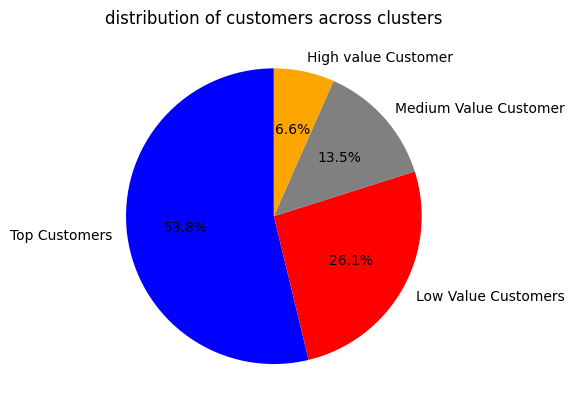

In [ ]:
plt.pie(rfm_data['Customer_segment'].value_counts(), labels=rfm_data['Customer_segment'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=['blue','red','grey','Orange','green'])
plt.title("distribution of customers across clusters")
plt.show()